In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from piwavelet.features.scalogram import (
    wavelet_scalogram,
)

from piwavelet.features.image import (
    resize_scalogram,
    to_uint8,
)



In [2]:
# ----------------------------------------------------------------------
# synthetic signal
# ----------------------------------------------------------------------

dt = 0.01

time = np.arange(
    0,
    10,
    dt,
)

signal = (
    np.sin(2 * np.pi * 5 * time)
    + 0.5 * np.sin(2 * np.pi * 20 * time)
)

# chirp component
signal += np.sin(
    2 * np.pi
    * (
        2
        + 8 * time
    )
    * time
)

# noise
signal += 0.2 * np.random.randn(
    time.size
)



In [3]:
# ----------------------------------------------------------------------
# compute wavelet scalogram
# ----------------------------------------------------------------------

scalogram = wavelet_scalogram(
    signal,
    dt=dt,
    output="power",
    log_transform=True,
    normalization="minmax",
)

print(
    "scalogram shape:",
    scalogram.shape,
)


scalogram shape: (109, 1000)


cnn image shape: (224, 224)
uint8


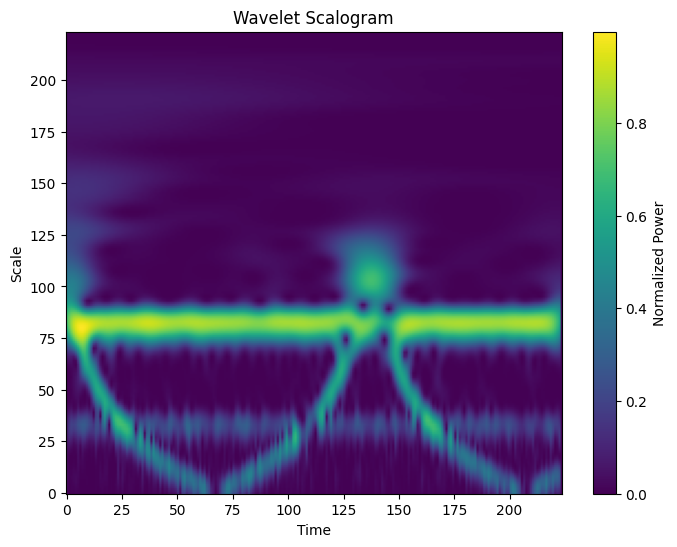

In [4]:

# ----------------------------------------------------------------------
# resize for CNN input
# ----------------------------------------------------------------------

image = resize_scalogram(
    scalogram,
    size=(224, 224),
)

print(
    "cnn image shape:",
    image.shape,
)

# ----------------------------------------------------------------------
# convert to uint8 image
# ----------------------------------------------------------------------

image_uint8 = to_uint8(
    image
)

print(
    image_uint8.dtype
)

# ----------------------------------------------------------------------
# visualize
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6)
)

im = ax.imshow(
    image,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)

ax.set_title(
    "Wavelet Scalogram"
)

ax.set_xlabel(
    "Time"
)

ax.set_ylabel(
    "Scale"
)

fig.colorbar(
    im,
    ax=ax,
    label="Normalized Power",
)

plt.show()